# 0825_kimjaehak_007_label_shift_diagnosis

시간 후반부의 `class=1` 증가가 검사유형 구성 변화, 측정 피처 분포 변화, 또는 동일 입력에 대한 라벨 판정 기준 변화 중 무엇과 더 관련되는지 진단합니다.

이 노트북은 새 모델의 성능 개선 실험이 아닙니다. `0824_kimjaehak_006_type_conditioned_baseline`을 고정 기준으로 사용해 `0825_lsw_005_drift_label_robust`의 핵심 전제인 시간에 따른 라벨 기준 변화를 독립적으로 검증합니다. 관찰 데이터만으로 작업자 변경이나 실제 불량 원인을 확정하지는 않습니다.

## 1. 설정과 라이브러리

In [1]:
from pathlib import Path
import json
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_007_label_shift_diagnosis"
BASELINE_ID = "0824_kimjaehak_006_type_conditioned_baseline"
RANDOM_STATE = 42
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
N_WINDOWS = 10
DECISION_THRESHOLD = 0.5
PSI_BINS = 10
PSI_EPSILON = 1e-6

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data/raw/dataset.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("data/raw/dataset.csv를 찾을 수 없습니다.")

DATA_PATH = REPO_ROOT / "data/raw/dataset.csv"
MAPPING_PATH = REPO_ROOT / "data/raw/mapping.json"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print("experiment:", EXPERIMENT_ID)
print("baseline:", BASELINE_ID)
print("python:", platform.python_version())
print("pandas:", pd.__version__)

experiment: 0825_kimjaehak_007_label_shift_diagnosis
baseline: 0824_kimjaehak_006_type_conditioned_baseline
python: 3.12.13
pandas: 3.0.5


## 2. 원본 로딩과 006 기준 중복 제거

두 데이터 뷰를 유지합니다.

- `raw_df`: 실제 반복 빈도와 동일 signature의 라벨 이력 분석
- `clean_df`: 006 baseline과 동일하게 `record_id`, `timestamp`를 제외하고 중복 제거한 모델 비교용 데이터

중복 판단에는 `class`가 포함되므로, 같은 입력이 서로 다른 라벨을 가진 경우 두 라벨은 모두 보존됩니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

required_columns = {RECORD_ID, TIME_COLUMN, TYPE_COLUMN, TARGET}
assert not (required_columns - set(raw_df.columns))
assert raw_df[RECORD_ID].is_unique

raw_df[TIME_COLUMN] = pd.to_datetime(raw_df[TIME_COLUMN], errors="raise", utc=True)

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy()
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

assert not clean_df.duplicated(subset=dedup_columns, keep=False).any()
assert len(clean_df) + int(duplicate_mask.sum()) == len(raw_df)

data_summary = pd.DataFrame(
    {
        "raw": [len(raw_df), int(raw_df[TARGET].sum()), raw_df[TARGET].mean() * 100],
        "baseline_dedup": [len(clean_df), int(clean_df[TARGET].sum()), clean_df[TARGET].mean() * 100],
    },
    index=["rows", "class_1", "class_1_rate_pct"],
)
data_summary

,raw,baseline_dedup
rows,"440,274.000000","391,992.000000"
class_1,"4,622.000000","4,436.000000"
class_1_rate_pct,1.049801,1.131656


## 3. 동일 timestamp 보존 60/20/20 분할과 10개 진단 윈도우

006의 Train/Validation/Test 경계를 그대로 재현합니다. 세부 변화 시점을 보기 위한 10개 윈도우도 동일 timestamp를 자르지 않고 누적 행 수가 10% 단위에 가장 가까운 경계로 구성합니다.

In [3]:
timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(target_fraction):
    position = int(
        np.searchsorted(cumulative_rows, len(clean_df) * target_fraction, side="left")
    )
    return timestamp_group_sizes.index[position]

train_end_time = boundary_time(0.60)
valid_end_time = boundary_time(0.80)

clean_df["split"] = np.select(
    [
        clean_df[TIME_COLUMN] <= train_end_time,
        clean_df[TIME_COLUMN] <= valid_end_time,
    ],
    ["train", "validation"],
    default="test",
)

window_end_times = pd.DatetimeIndex(
    [boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)]
)
window_end_ns = window_end_times.astype("int64").to_numpy()
window_number = np.searchsorted(
    window_end_ns,
    clean_df[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
clean_df["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in window_number],
    categories=[f"W{number:02d}" for number in range(1, N_WINDOWS + 1)],
    ordered=True,
)

split_summary = clean_df.groupby("split", observed=True).agg(
    rows=(TARGET, "size"),
    class_1=(TARGET, "sum"),
    class_1_rate=(TARGET, "mean"),
    timestamp_groups=(TIME_COLUMN, "nunique"),
    start_time=(TIME_COLUMN, "min"),
    end_time=(TIME_COLUMN, "max"),
).reindex(["train", "validation", "test"])
split_summary["class_1_rate_pct"] = split_summary["class_1_rate"] * 100

window_summary_base = clean_df.groupby("window", observed=False).agg(
    rows=(TARGET, "size"),
    class_1=(TARGET, "sum"),
    class_1_rate=(TARGET, "mean"),
    timestamp_groups=(TIME_COLUMN, "nunique"),
    start_time=(TIME_COLUMN, "min"),
    end_time=(TIME_COLUMN, "max"),
)

assert split_summary["rows"].sum() == len(clean_df)
assert window_summary_base["rows"].sum() == len(clean_df)
assert clean_df.groupby(TIME_COLUMN)["window"].nunique().max() == 1

display(split_summary[["rows", "class_1", "class_1_rate_pct", "timestamp_groups", "start_time", "end_time"]])
display(window_summary_base)

,rows,class_1,class_1_rate_pct,timestamp_groups,start_time,end_time
split,,,,,,
train,235222,1824,0.775438,25501,1970-06-23 03:58:55+00:00,1970-09-28 05:48:26+00:00
validation,78374,363,0.463164,6282,1970-09-28 05:49:10+00:00,1970-10-13 13:14:26+00:00
test,78396,2249,2.868769,7165,1970-10-13 13:14:58+00:00,1970-11-02 14:21:28+00:00


,rows,class_1,class_1_rate,timestamp_groups,start_time,end_time
window,,,,,,
W01,39210,73,0.001862,3855,1970-06-23 03:58:55+00:00,1970-07-11 09:04:23+00:00
W02,39196,712,0.018165,6335,1970-07-11 09:06:50+00:00,1970-08-02 17:57:15+00:00
W03,39202,414,0.010561,4705,1970-08-02 17:58:53+00:00,1970-08-18 04:33:04+00:00
W04,39192,201,0.005129,2076,1970-08-18 04:33:34+00:00,1970-08-25 14:06:02+00:00
W05,39202,277,0.007066,4681,1970-08-25 14:06:56+00:00,1970-09-15 16:53:19+00:00
W06,39220,147,0.003748,3849,1970-09-15 16:54:22+00:00,1970-09-28 05:48:26+00:00
W07,39180,36,0.000919,3107,1970-09-28 05:49:10+00:00,1970-10-05 10:38:10+00:00
W08,39194,327,0.008343,3175,1970-10-05 10:39:05+00:00,1970-10-13 13:14:26+00:00
W09,39197,941,0.024007,4670,1970-10-13 13:14:58+00:00,1970-10-25 07:10:56+00:00


## 4. 시간 구간별 `class=1` 추세와 신뢰구간

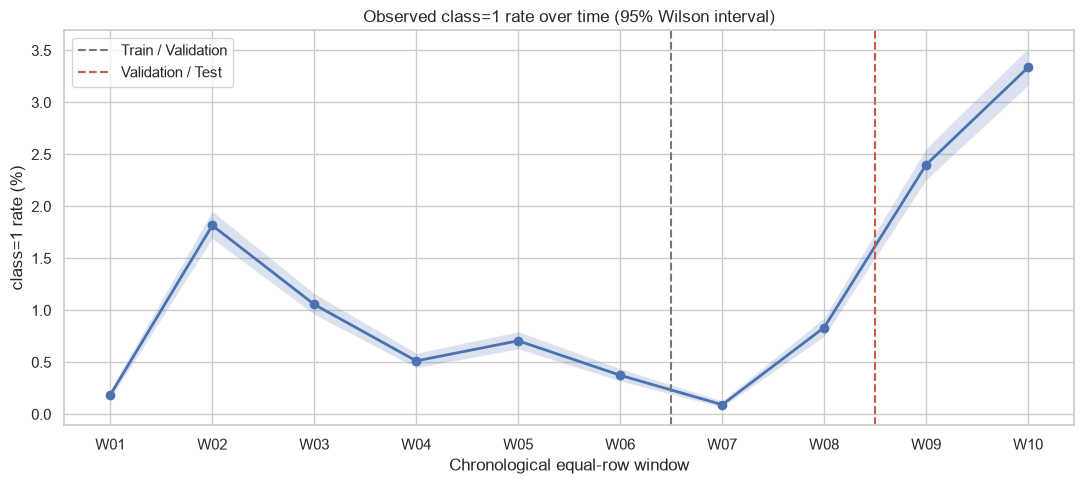

,rows,class_1,class_1_rate_pct,ci_low_pct,ci_high_pct,start_time,end_time
window,,,,,,,
W01,39210,73,0.186177,0.148112,0.234002,1970-06-23 03:58:55+00:00,1970-07-11 09:04:23+00:00
W02,39196,712,1.816512,1.688943,1.953525,1970-07-11 09:06:50+00:00,1970-08-02 17:57:15+00:00
W03,39202,414,1.056069,0.959565,1.162164,1970-08-02 17:58:53+00:00,1970-08-18 04:33:04+00:00
W04,39192,201,0.512860,0.446828,0.588592,1970-08-18 04:33:34+00:00,1970-08-25 14:06:02+00:00
W05,39202,277,0.706597,0.628372,0.794481,1970-08-25 14:06:56+00:00,1970-09-15 16:53:19+00:00
W06,39220,147,0.374809,0.319000,0.440338,1970-09-15 16:54:22+00:00,1970-09-28 05:48:26+00:00
W07,39180,36,0.091884,0.066380,0.127173,1970-09-28 05:49:10+00:00,1970-10-05 10:38:10+00:00
W08,39194,327,0.834311,0.748954,0.929306,1970-10-05 10:39:05+00:00,1970-10-13 13:14:26+00:00
W09,39197,941,2.400694,2.253756,2.556961,1970-10-13 13:14:58+00:00,1970-10-25 07:10:56+00:00


In [4]:
def wilson_interval(positive, total, z=1.96):
    positive = np.asarray(positive, dtype=float)
    total = np.asarray(total, dtype=float)
    rate = positive / total
    denominator = 1 + (z**2 / total)
    center = (rate + z**2 / (2 * total)) / denominator
    margin = (
        z
        * np.sqrt(rate * (1 - rate) / total + z**2 / (4 * total**2))
        / denominator
    )
    return center - margin, center + margin

window_summary = window_summary_base.copy()
ci_low, ci_high = wilson_interval(window_summary["class_1"], window_summary["rows"])
window_summary["class_1_rate_pct"] = window_summary["class_1_rate"] * 100
window_summary["ci_low_pct"] = ci_low * 100
window_summary["ci_high_pct"] = ci_high * 100

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(window_summary))
ax.plot(x, window_summary["class_1_rate_pct"], marker="o", linewidth=2)
ax.fill_between(x, window_summary["ci_low_pct"], window_summary["ci_high_pct"], alpha=0.2)
ax.axvline(5.5, color="#777777", linestyle="--", label="Train / Validation")
ax.axvline(7.5, color="#c95a49", linestyle="--", label="Validation / Test")
ax.set(
    xticks=x,
    xticklabels=window_summary.index.astype(str),
    xlabel="Chronological equal-row window",
    ylabel="class=1 rate (%)",
    title="Observed class=1 rate over time (95% Wilson interval)",
)
ax.legend()
plt.tight_layout()
plt.show()

window_summary[["rows", "class_1", "class_1_rate_pct", "ci_low_pct", "ci_high_pct", "start_time", "end_time"]]

## 5. inspection_type 내부 변화와 구성 효과 분해

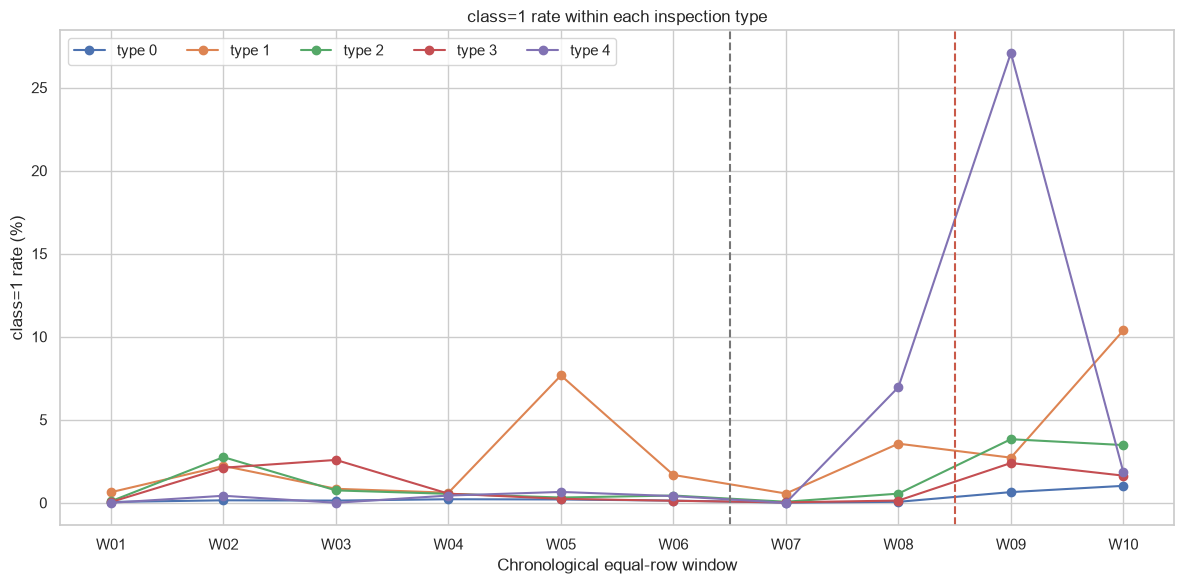

rows  class_1  class_1_rate  class_1_rate_pct
window inspection_type                                                
W01    0                 7979        4      0.000501          0.050132
       1                 8466       54      0.006378          0.637845
       2                 9469        9      0.000950          0.095047
       3                12997        6      0.000462          0.046164
       4                  299        0      0.000000          0.000000
W02    0                 8776       13      0.001481          0.148131
       1                 7167      159      0.022185          2.218501
       2                10225      281      0.027482          2.748166
       3                12081      255      0.021108          2.110752
       4                  947        4      0.004224          0.422386
W03    0                 7578       10      0.001320          0.131961
       1                 6526       55      0.008428          0.842783
       2                15843      118      0.007448          0.744808
       3                 8954      231      0.025799          2.579853
       4                  301        0      0.000000          0.000000
W04    0                 4219        9      0.002133          0.213321
       1                 4785       29      0.006061          0.606061
       2                17056       92      0.005394          0.539400
       3                12213       67      0.005486          0.548596
       4                  919        4      0.004353          0.435256
W05    0                 5014       10      0.001994          0.199442
       1                 2322      178      0.076658          7.665805
       2                15209       48      0.003156          0.315603
       3                16351       39      0.002385          0.238518
       4                  306        2      0.006536          0.653595
W06    0                 8395       11      0.001310          0.131030
       1                 4775       80      0.016754          1.675393
       2                 7108       31      0.004361          0.436128
       3                18196       22      0.001209          0.120906
       4                  746        3      0.004021          0.402145
W07    0                11337        1      0.000088          0.008821
       1                 4480       25      0.005580          0.558036
       2                11359        7      0.000616          0.061625
       3                11703        3      0.000256          0.025634
       4                  301        0      0.000000          0.000000
W08    0                12155        7      0.000576          0.057589
       1                 6014      214      0.035584          3.558364
       2                 4538       25      0.005509          0.550903
       3                15625       21      0.001344          0.134400
       4                  862       60      0.069606          6.960557
W09    0                10115       65      0.006426          0.642610
       1                 4822      131      0.027167          2.716715
       2                10635      407      0.038270          3.826986
       3                13577      325      0.023938          2.393754
       4                   48       13      0.270833         27.083333
W10    0                 6669       68      0.010196          1.019643
       1                 6290      653      0.103816         10.381558
       2                 8518      296      0.034750          3.474994
       3                17014      278      0.016339          1.633949
       4                  708       13      0.018362          1.836158

,observed_difference_pp,composition_effect_pp,within_type_effect_pp
window,,,
W01,0.000000,0.000000,0.000000
W02,1.630335,-0.039240,1.669575
W03,0.869892,-0.104558,0.974449
W04,0.326683,-0.011994,0.338677
W05,0.520420,-0.617631,1.138051
W06,0.188632,-0.110604,0.299236
W07,-0.094293,-0.055585,-0.038708
W08,0.648134,-0.109863,0.757998
W09,2.214517,-0.146915,2.361432


In [5]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique())

type_window = clean_df.groupby(["window", TYPE_COLUMN], observed=False)[TARGET].agg(
    rows="size", class_1="sum", class_1_rate="mean"
).reset_index()
type_window["class_1_rate_pct"] = type_window["class_1_rate"] * 100

type_rate_pivot = type_window.pivot(index="window", columns=TYPE_COLUMN, values="class_1_rate")
type_count_pivot = type_window.pivot(index="window", columns=TYPE_COLUMN, values="rows")
type_weight_pivot = type_count_pivot.div(type_count_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
for inspection_type in inspection_types:
    ax.plot(
        np.arange(N_WINDOWS),
        type_rate_pivot[inspection_type] * 100,
        marker="o",
        label=f"type {inspection_type}",
    )
ax.axvline(5.5, color="#777777", linestyle="--")
ax.axvline(7.5, color="#c95a49", linestyle="--")
ax.set(
    xticks=np.arange(N_WINDOWS),
    xticklabels=type_rate_pivot.index.astype(str),
    xlabel="Chronological equal-row window",
    ylabel="class=1 rate (%)",
    title="class=1 rate within each inspection type",
)
ax.legend(ncol=5)
plt.tight_layout()
plt.show()

# Kitagawa decomposition: each window's rate difference from W01.
reference_window = type_rate_pivot.index[0]
reference_rates = type_rate_pivot.loc[reference_window]
reference_weights = type_weight_pivot.loc[reference_window]
decomposition_rows = []
for window in type_rate_pivot.index:
    rates = type_rate_pivot.loc[window]
    weights = type_weight_pivot.loc[window]
    composition_effect = 0.5 * ((weights - reference_weights) * (rates + reference_rates)).sum()
    within_type_effect = 0.5 * ((rates - reference_rates) * (weights + reference_weights)).sum()
    observed_difference = (
        (weights * rates).sum() - (reference_weights * reference_rates).sum()
    )
    decomposition_rows.append(
        {
            "window": str(window),
            "observed_difference_pp": observed_difference * 100,
            "composition_effect_pp": composition_effect * 100,
            "within_type_effect_pp": within_type_effect * 100,
        }
    )

decomposition = pd.DataFrame(decomposition_rows).set_index("window")
assert np.allclose(
    decomposition["observed_difference_pp"],
    decomposition["composition_effect_pp"] + decomposition["within_type_effect_pp"],
)

display(type_window.set_index(["window", TYPE_COLUMN]))
decomposition

## 6. inspection_type·meta 구성만으로 기대되는 라벨 비율

Train의 `inspection_type`, `meta_feat1`~`meta_feat4`와 라벨 관계만 학습한 additive logistic model을 구성합니다. 미래 윈도우의 범주 구성만 바뀌었을 때 기대되는 라벨 비율과 실제 비율의 차이를 봅니다. 이는 인과 추정이나 최종 예측 모델이 아니라 구성 변화 설명력을 확인하는 보조 진단입니다.

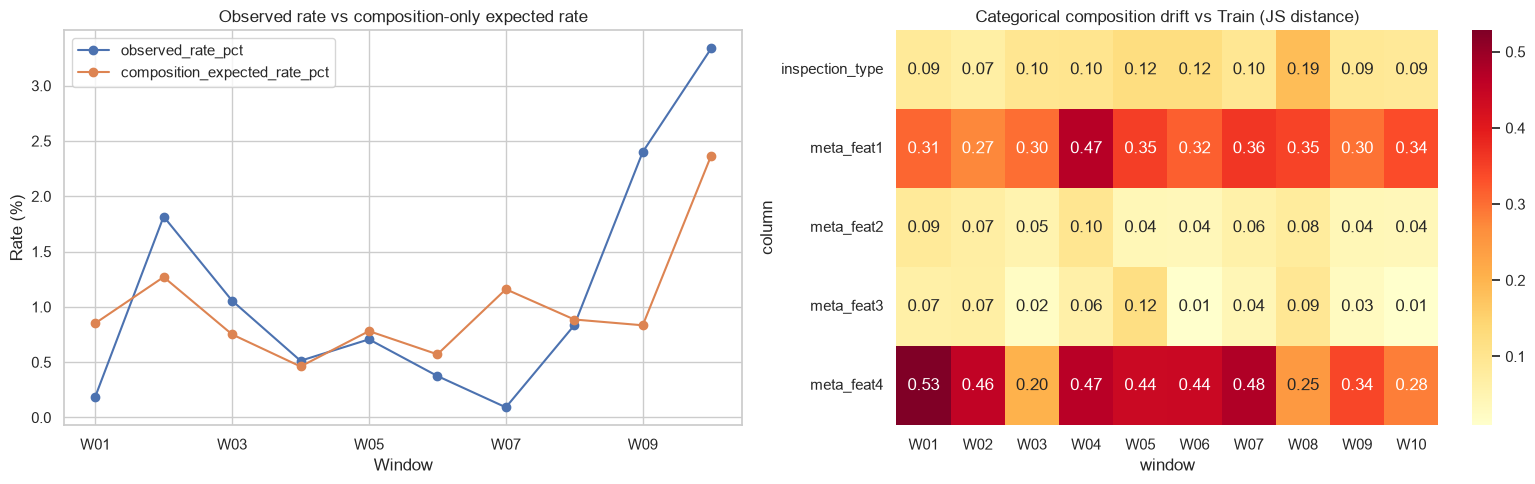

,observed_rate,composition_expected_rate,observed_rate_pct,composition_expected_rate_pct,unexplained_gap_pp
window,,,,,
W01,0.001862,0.008515,0.186177,0.851484,-0.665307
W02,0.018165,0.012697,1.816512,1.269750,0.546762
W03,0.010561,0.007513,1.056069,0.751343,0.304726
W04,0.005129,0.004611,0.512860,0.461111,0.051749
W05,0.007066,0.007810,0.706597,0.780990,-0.074393
W06,0.003748,0.005710,0.374809,0.570969,-0.196160
W07,0.000919,0.011596,0.091884,1.159606,-1.067723
W08,0.008343,0.008859,0.834311,0.885902,-0.051590
W09,0.024007,0.008336,2.400694,0.833565,1.567129


In [6]:
meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
composition_columns = [TYPE_COLUMN] + meta_columns
train_mask = clean_df["split"] == "train"

composition_model = Pipeline(
    steps=[
        (
            "categorical",
            ColumnTransformer(
                [("onehot", OneHotEncoder(handle_unknown="ignore"), composition_columns)],
                remainder="drop",
            ),
        ),
        (
            "model",
            LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        ),
    ]
)
composition_model.fit(clean_df.loc[train_mask, composition_columns], clean_df.loc[train_mask, TARGET])
clean_df["composition_expected_probability"] = composition_model.predict_proba(
    clean_df[composition_columns]
)[:, 1]

composition_window = clean_df.groupby("window", observed=False).agg(
    observed_rate=(TARGET, "mean"),
    composition_expected_rate=("composition_expected_probability", "mean"),
)
composition_window["observed_rate_pct"] = composition_window["observed_rate"] * 100
composition_window["composition_expected_rate_pct"] = (
    composition_window["composition_expected_rate"] * 100
)
composition_window["unexplained_gap_pp"] = (
    composition_window["observed_rate_pct"]
    - composition_window["composition_expected_rate_pct"]
)

def jensen_shannon_distance(reference, current, epsilon=1e-12):
    categories = reference.index.union(current.index)
    p = reference.reindex(categories, fill_value=0).to_numpy(dtype=float)
    q = current.reindex(categories, fill_value=0).to_numpy(dtype=float)
    p = np.clip(p / p.sum(), epsilon, None)
    q = np.clip(q / q.sum(), epsilon, None)
    p /= p.sum()
    q /= q.sum()
    midpoint = 0.5 * (p + q)
    divergence = 0.5 * np.sum(p * np.log(p / midpoint)) + 0.5 * np.sum(q * np.log(q / midpoint))
    return float(np.sqrt(divergence))

train_df = clean_df.loc[train_mask]
categorical_drift_rows = []
for column in composition_columns:
    reference_share = train_df[column].value_counts(normalize=True, dropna=False)
    for window, group in clean_df.groupby("window", observed=False):
        current_share = group[column].value_counts(normalize=True, dropna=False)
        categorical_drift_rows.append(
            {
                "column": column,
                "window": str(window),
                "js_distance": jensen_shannon_distance(reference_share, current_share),
            }
        )

categorical_drift = pd.DataFrame(categorical_drift_rows)
categorical_drift_pivot = categorical_drift.pivot(
    index="column", columns="window", values="js_distance"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
composition_window[["observed_rate_pct", "composition_expected_rate_pct"]].plot(
    marker="o", ax=axes[0]
)
axes[0].set_title("Observed rate vs composition-only expected rate")
axes[0].set_ylabel("Rate (%)")
axes[0].set_xlabel("Window")
sns.heatmap(categorical_drift_pivot, cmap="YlOrRd", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Categorical composition drift vs Train (JS distance)")
plt.tight_layout()
plt.show()

composition_window

## 7. 동일 입력 signature의 라벨 전환

`record_id`, `timestamp`, `class`를 제외한 모든 입력이 동일한 행을 하나의 signature로 정의합니다. 64-bit pandas hash로 후보를 집계한 뒤 라벨 충돌 hash는 실제 컬럼으로 다시 확인합니다.

두 가지 방향을 구분합니다.

- **최초 등장 순서**: 각 라벨이 처음 관찰된 시점 비교. 중복 제거 데이터의 140행 분석과 대응합니다.
- **원본 endpoint 방향**: 원본 반복행에서 최초 timestamp와 최종 timestamp의 라벨 집합 비교. 중간 재전환과 같은 시점의 mixed label을 보존합니다.

In [7]:
signature_columns = [
    column
    for column in raw_df.columns
    if column not in {RECORD_ID, TIME_COLUMN, TARGET}
]
raw_signature_hash = pd.util.hash_pandas_object(
    raw_df[signature_columns], index=False, categorize=True
).astype("uint64")
raw_signature_stats = pd.DataFrame(
    {
        "signature_hash": raw_signature_hash,
        TARGET: raw_df[TARGET].to_numpy(),
    }
).groupby("signature_hash")[TARGET].agg(rows="size", label_nunique="nunique")
conflict_hashes = raw_signature_stats.index[raw_signature_stats["label_nunique"] > 1]

# Hash collision guard for the small set that affects the conclusion.
for signature_hash in conflict_hashes:
    rows = raw_df.loc[raw_signature_hash == signature_hash, signature_columns]
    assert len(rows.drop_duplicates()) == 1, "라벨 충돌 후보에서 hash collision 발견"

conflict_raw = raw_df.loc[raw_signature_hash.isin(conflict_hashes)].copy()
conflict_raw["signature_hash"] = raw_signature_hash.loc[
    raw_signature_hash.isin(conflict_hashes)
].to_numpy()

clean_signature_hash = pd.util.hash_pandas_object(
    clean_df[signature_columns], index=False, categorize=True
).astype("uint64")
conflict_clean = clean_df.loc[clean_signature_hash.isin(conflict_hashes)].copy()
conflict_clean["signature_hash"] = clean_signature_hash.loc[
    clean_signature_hash.isin(conflict_hashes)
].to_numpy()

reconciliation = pd.Series(
    {
        "conflict_groups": len(conflict_hashes),
        "raw_rows_in_conflict_groups": len(conflict_raw),
        "baseline_dedup_rows_in_conflict_groups": len(conflict_clean),
        "largest_raw_group_rows": int(raw_signature_stats.loc[conflict_hashes, "rows"].max()),
    },
    name="signature_reconciliation",
)

first_arrival_rows = []
endpoint_rows = []
for signature_hash, group in conflict_raw.groupby("signature_hash", sort=False):
    ordered = group.sort_values([TIME_COLUMN, RECORD_ID], kind="stable")
    first_time_by_label = ordered.groupby(TARGET)[TIME_COLUMN].min()
    if first_time_by_label.loc[0] < first_time_by_label.loc[1]:
        first_direction = "0_to_1"
    elif first_time_by_label.loc[1] < first_time_by_label.loc[0]:
        first_direction = "1_to_0"
    else:
        first_direction = "same_time"
    first_arrival_rows.append(
        {
            "signature_hash": signature_hash,
            "direction": first_direction,
            "gap_days": abs(
                (first_time_by_label.loc[1] - first_time_by_label.loc[0]).total_seconds()
            ) / 86400,
            "rows": len(ordered),
            "inspection_type": int(ordered[TYPE_COLUMN].iloc[0]),
        }
    )

    earliest_time = ordered[TIME_COLUMN].min()
    latest_time = ordered[TIME_COLUMN].max()
    earliest_labels = frozenset(ordered.loc[ordered[TIME_COLUMN] == earliest_time, TARGET])
    latest_labels = frozenset(ordered.loc[ordered[TIME_COLUMN] == latest_time, TARGET])
    if earliest_labels == {0} and latest_labels == {1}:
        endpoint_direction = "0_to_1"
    elif earliest_labels == {1} and latest_labels == {0}:
        endpoint_direction = "1_to_0"
    elif earliest_labels == latest_labels:
        endpoint_direction = "same_or_mixed"
    else:
        endpoint_direction = "ambiguous"
    endpoint_rows.append(
        {
            "signature_hash": signature_hash,
            "direction": endpoint_direction,
            "rows": len(ordered),
            "inspection_type": int(ordered[TYPE_COLUMN].iloc[0]),
        }
    )

first_arrival = pd.DataFrame(first_arrival_rows)
endpoints = pd.DataFrame(endpoint_rows)
first_direction_counts = first_arrival["direction"].value_counts()
endpoint_direction_counts = endpoints["direction"].value_counts()

def exact_two_sided_binomial_p(successes, trials):
    if trials == 0:
        return np.nan
    lower = min(successes, trials - successes)
    one_tail = sum(math.comb(trials, value) for value in range(lower + 1)) / (2**trials)
    return min(1.0, 2 * one_tail)

directional_trials = int(
    first_direction_counts.get("0_to_1", 0) + first_direction_counts.get("1_to_0", 0)
)
directional_successes = int(first_direction_counts.get("0_to_1", 0))
first_arrival_p_value = exact_two_sided_binomial_p(directional_successes, directional_trials)

raw_window_number = np.searchsorted(
    window_end_ns,
    conflict_raw[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
conflict_raw["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in raw_window_number],
    categories=clean_df["window"].cat.categories,
    ordered=True,
)
conflict_window_row_weighted = conflict_raw.groupby("window", observed=False)[TARGET].mean()
conflict_signature_window = conflict_raw.groupby(
    ["window", "signature_hash"], observed=False
)[TARGET].mean().dropna()
conflict_window_group_balanced = conflict_signature_window.groupby("window", observed=False).mean()

display(reconciliation)
display(pd.DataFrame({"first_arrival": first_direction_counts, "raw_endpoints": endpoint_direction_counts}).fillna(0).astype(int))
display(first_arrival.groupby(["inspection_type", "direction"]).size().unstack(fill_value=0))
print(f"first-arrival exact binomial p-value: {first_arrival_p_value:.3e}")
pd.DataFrame(
    {
        "row_weighted_class_1_rate": conflict_window_row_weighted,
        "group_balanced_class_1_rate": conflict_window_group_balanced,
    }
)

conflict_groups                              70
raw_rows_in_conflict_groups               14037
baseline_dedup_rows_in_conflict_groups      140
largest_raw_group_rows                     5546
Name: signature_reconciliation, dtype: int64

,first_arrival,raw_endpoints
direction,,
0_to_1,57,33
1_to_0,13,12
ambiguous,0,2
same_or_mixed,0,23


direction,0_to_1,1_to_0
inspection_type,,
0,16,1
1,1,0
2,28,9
3,12,3


first-arrival exact binomial p-value: 1.029e-07


,row_weighted_class_1_rate,group_balanced_class_1_rate
window,,
W01,0.000000,0.000000
W02,0.003484,0.063509
W03,0.014808,0.227509
W04,0.002259,0.111756
W05,0.067485,0.115670
W06,0.014085,0.031890
W07,0.004032,0.001506
W08,0.006410,0.004283
W09,0.012108,0.332237


## 8. mapping 유효 피처의 시간별 PSI

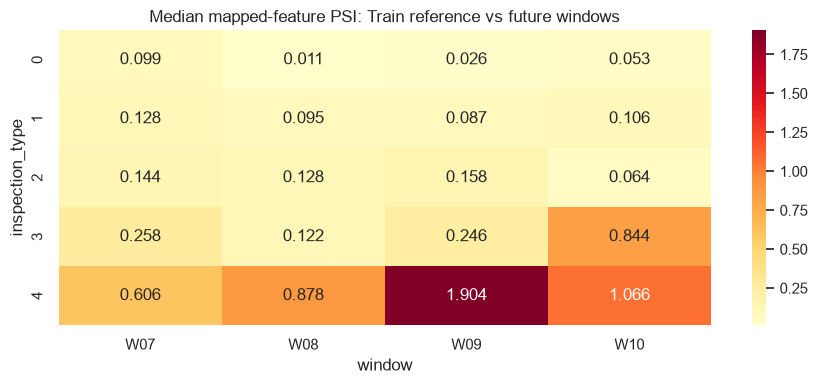

evaluated_features  large_features  median_psi  \
inspection_type window                                                   
0               W07                     37              12    0.099209   
                W08                     37               2    0.010974   
                W09                     37               3    0.025533   
                W10                     37               1    0.052910   
1               W07                     24              11    0.128496   
                W08                     24               7    0.095272   
                W09                     24               8    0.086877   
                W10                     24              10    0.105593   
2               W07                     20               7    0.143809   
                W08                     20               4    0.128099   
                W09                     20               9    0.157636   
                W10                     20               2    0.063529   
3               W07                     19              10    0.257960   
                W08                     19               5    0.122469   
                W09                     19               8    0.246459   
                W10                     19              16    0.843574   
4               W07                     13              12    0.606376   
                W08                     13              12    0.877601   
                W09                     13              12    1.903915   
                W10                     13              11    1.065796   

                        max_psi  
inspection_type window           
0               W07    0.665896  
                W08    0.327271  
                W09    0.388223  
                W10    0.267214  
1               W07    1.415712  
                W08    1.301125  
                W09    1.876516  
                W10    1.555867  
2               W07    1.793562  
                W08    0.859626  
                W09    1.453224  
                W10    0.545024  
3               W07    1.053906  
                W08    0.693510  
                W09    1.059570  
                W10    1.200197  
4               W07    5.146078  
                W08    4.377373  
                W09    6.536029  
                W10    4.182627

,inspection_type,window,feature,psi,large_drift
432,4,W09,inspection_feat7,6.536029,True
406,4,W07,inspection_feat7,5.146078,True
419,4,W08,inspection_feat7,4.377373,True
445,4,W10,inspection_feat7,4.182627,True
438,4,W09,inspection_feat34,3.676816,True
434,4,W09,inspection_feat9,3.061325,True
426,4,W09,inspection_feat1,2.802454,True
437,4,W09,inspection_feat33,2.510520,True
431,4,W09,inspection_feat6,2.510520,True
442,4,W10,inspection_feat4,2.095074,True


In [8]:
with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)

def population_stability_index(reference, current, max_bins=10, epsilon=1e-6):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    reference = reference[np.isfinite(reference)]
    current = current[np.isfinite(current)]
    if reference.size == 0 or current.size == 0:
        return np.nan
    unique_reference = np.unique(reference)
    if unique_reference.size <= 1:
        return np.nan
    if unique_reference.size <= max_bins:
        interior_edges = (unique_reference[:-1] + unique_reference[1:]) / 2
    else:
        quantiles = np.linspace(0, 1, max_bins + 1)[1:-1]
        interior_edges = np.unique(np.quantile(reference, quantiles))
    edges = np.concatenate(([-np.inf], interior_edges, [np.inf]))
    reference_counts = np.histogram(reference, bins=edges)[0].astype(float)
    current_counts = np.histogram(current, bins=edges)[0].astype(float)
    reference_share = np.clip(reference_counts / reference_counts.sum(), epsilon, None)
    current_share = np.clip(current_counts / current_counts.sum(), epsilon, None)
    reference_share /= reference_share.sum()
    current_share /= current_share.sum()
    return float(np.sum((current_share - reference_share) * np.log(current_share / reference_share)))

future_windows = [f"W{number:02d}" for number in range(7, 11)]
psi_rows = []
for inspection_type in inspection_types:
    train_type = clean_df.loc[train_mask & (clean_df[TYPE_COLUMN] == inspection_type)]
    mapped_features = feature_mapping[str(inspection_type)]
    evaluable_features = [
        feature for feature in mapped_features if train_type[feature].nunique(dropna=False) > 1
    ]
    for window in future_windows:
        current_type = clean_df.loc[
            (clean_df["window"] == window) & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        for feature in evaluable_features:
            psi_rows.append(
                {
                    "inspection_type": inspection_type,
                    "window": window,
                    "feature": feature,
                    "psi": population_stability_index(
                        train_type[feature], current_type[feature], PSI_BINS, PSI_EPSILON
                    ),
                }
            )

psi_results = pd.DataFrame(psi_rows).dropna()
psi_results["large_drift"] = psi_results["psi"] >= 0.25
psi_summary = psi_results.groupby(["inspection_type", "window"]).agg(
    evaluated_features=("feature", "size"),
    large_features=("large_drift", "sum"),
    median_psi=("psi", "median"),
    max_psi=("psi", "max"),
)

median_psi_pivot = psi_summary["median_psi"].unstack("window")
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(median_psi_pivot, cmap="YlOrRd", annot=True, fmt=".3f", ax=ax)
ax.set_title("Median mapped-feature PSI: Train reference vs future windows")
plt.tight_layout()
plt.show()

display(psi_summary)
psi_results.sort_values("psi", ascending=False).head(20)

## 9. 006 type-conditioned baseline의 고정 미래 예측

006과 동일한 공통 split, mapping 피처, 기본 XGBoost 설정으로 Train에서만 5개 모델을 학습합니다. Validation과 Test를 합친 미래 4개 윈도우에 모델을 고정 적용합니다. 모델 점수 상승이 실제 라벨 비율 상승을 따라가는지 확인하며, 모델이나 threshold를 미래 결과에 맞춰 변경하지 않습니다.

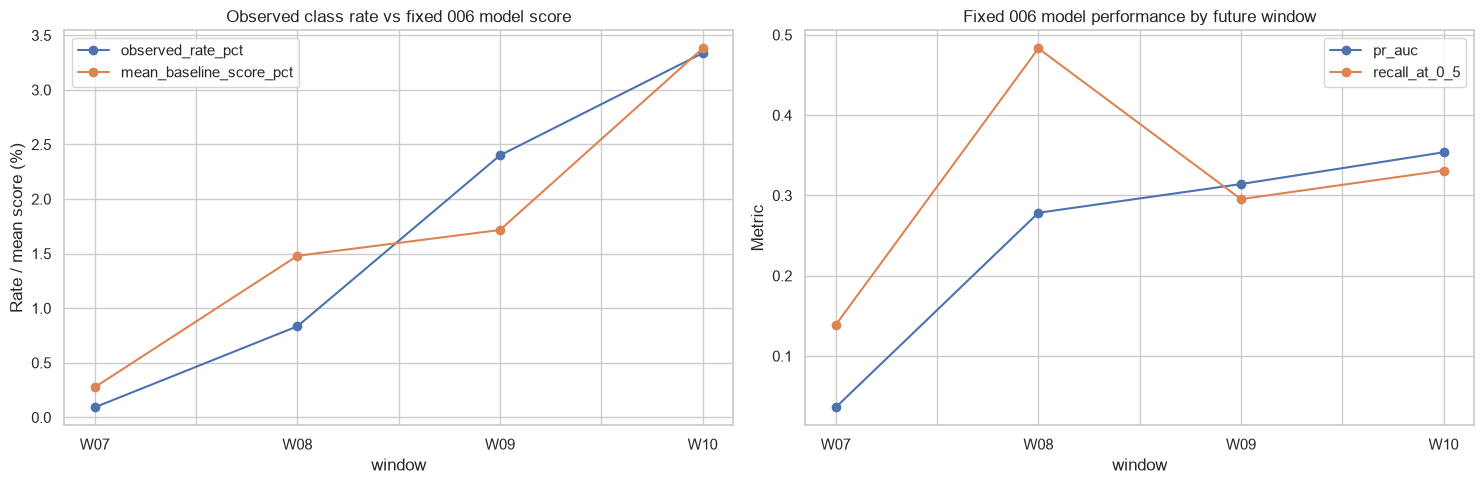

,split,rows,class_1,observed_rate_pct,mean_baseline_score_pct,calibration_gap_pp,pr_auc,recall_at_0_5
window,,,,,,,,
W07,validation,39180,36,0.091884,0.276038,-0.184154,0.036102,0.138889
W08,validation,39194,327,0.834311,1.479944,-0.645633,0.278423,0.483180
W09,test,39197,941,2.400694,1.716793,0.683901,0.314224,0.295430
W10,test,39199,1308,3.336820,3.380174,-0.043354,0.353813,0.331040


rows            78,396.000000
class_1          2,249.000000
pr_auc               0.315411
recall_at_0_5        0.316141
Name: reproduced_006_test, dtype: float64

rows  class_1  observed_rate_pct  mean_score_pct  \
window inspection_type                                                      
W07    0                11337        1           0.008821        0.037574   
       1                 4480       25           0.558036        1.844594   
       2                11359        7           0.061625        0.102614   
       3                11703        3           0.025634        0.073117   
       4                  301        0           0.000000        0.345900   
W08    0                12155        7           0.057589        0.011301   
       1                 6014      214           3.558364        5.904329   
       2                 4538       25           0.550903        1.939300   
       3                15625       21           0.134400        0.819537   
       4                  862       60           6.960557        0.873719   
W09    0                10115       65           0.642610        0.027046   
       1                 4822      131           2.716715        4.820235   
       2                10635      407           3.826986        3.583518   
       3                13577      325           2.393754        0.417044   
       4                   48       13          27.083333        0.072489   
W10    0                 6669       68           1.019643        0.054991   
       1                 6290      653          10.381558       14.722940   
       2                 8518      296           3.474994        1.518562   
       3                17014      278           1.633949        1.370894   
       4                  708       13           1.836158        4.612889   

                         pr_auc  recall_at_0_5  
window inspection_type                          
W07    0               0.000325       0.000000  
       1               0.042467       0.160000  
       2               0.011002       0.000000  
       3               0.124024       0.333333  
       4                    NaN       0.000000  
W08    0               0.008086       0.000000  
       1               0.658596       0.672897  
       2               0.063254       0.280000  
       3               0.155799       0.285714  
       4               0.068228       0.016667  
W09    0               0.056140       0.000000  
       1               0.161149       0.267176  
       2               0.435719       0.498771  
       3               0.494138       0.123077  
       4               0.212816       0.000000  
W10    0               0.099166       0.014706  
       1               0.515162       0.493109  
       2               0.223500       0.135135  
       3               0.252306       0.251799  
       4               0.013147       0.000000

In [9]:
feature_columns_by_type = {}
models_by_type = {}
baseline_probability = pd.Series(np.nan, index=clean_df.index, dtype="float64")

for inspection_type in inspection_types:
    feature_columns = meta_columns + feature_mapping[str(inspection_type)]
    feature_columns_by_type[inspection_type] = feature_columns
    type_train = clean_df.loc[train_mask & (clean_df[TYPE_COLUMN] == inspection_type)]
    type_validation = clean_df.loc[
        (clean_df["split"] == "validation") & (clean_df[TYPE_COLUMN] == inspection_type)
    ]
    type_future = clean_df.loc[
        (~train_mask) & (clean_df[TYPE_COLUMN] == inspection_type)
    ]

    model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )
    model.fit(
        type_train[feature_columns],
        type_train[TARGET].astype("int8"),
        eval_set=[(type_validation[feature_columns], type_validation[TARGET].astype("int8"))],
        verbose=False,
    )
    models_by_type[inspection_type] = model
    baseline_probability.loc[type_future.index] = model.predict_proba(
        type_future[feature_columns]
    )[:, 1]

future_mask = ~train_mask
assert baseline_probability.loc[future_mask].notna().all()

def safe_average_precision(y_true, probabilities):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, probabilities)

future_model_rows = []
for window in future_windows:
    group = clean_df.loc[clean_df["window"] == window]
    probabilities = baseline_probability.loc[group.index]
    predictions = (probabilities >= DECISION_THRESHOLD).astype("int8")
    future_model_rows.append(
        {
            "window": window,
            "split": group["split"].iloc[0],
            "rows": len(group),
            "class_1": int(group[TARGET].sum()),
            "observed_rate_pct": group[TARGET].mean() * 100,
            "mean_baseline_score_pct": probabilities.mean() * 100,
            "calibration_gap_pp": (group[TARGET].mean() - probabilities.mean()) * 100,
            "pr_auc": safe_average_precision(group[TARGET], probabilities),
            "recall_at_0_5": recall_score(group[TARGET], predictions, zero_division=0),
        }
    )

future_model_summary = pd.DataFrame(future_model_rows).set_index("window")

type_future_rows = []
for window in future_windows:
    for inspection_type in inspection_types:
        group = clean_df.loc[
            (clean_df["window"] == window) & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        probabilities = baseline_probability.loc[group.index]
        predictions = (probabilities >= DECISION_THRESHOLD).astype("int8")
        type_future_rows.append(
            {
                "window": window,
                "inspection_type": inspection_type,
                "rows": len(group),
                "class_1": int(group[TARGET].sum()),
                "observed_rate_pct": group[TARGET].mean() * 100,
                "mean_score_pct": probabilities.mean() * 100,
                "pr_auc": safe_average_precision(group[TARGET], probabilities),
                "recall_at_0_5": recall_score(group[TARGET], predictions, zero_division=0),
            }
        )
type_future_summary = pd.DataFrame(type_future_rows).set_index(["window", "inspection_type"])

test_group = clean_df.loc[clean_df["split"] == "test"]
test_probabilities = baseline_probability.loc[test_group.index]
test_predictions = (test_probabilities >= DECISION_THRESHOLD).astype("int8")
baseline_test_summary = pd.Series(
    {
        "rows": len(test_group),
        "class_1": int(test_group[TARGET].sum()),
        "pr_auc": average_precision_score(test_group[TARGET], test_probabilities),
        "recall_at_0_5": recall_score(test_group[TARGET], test_predictions),
    },
    name="reproduced_006_test",
)
assert np.isclose(baseline_test_summary["pr_auc"], 0.315411, atol=5e-6)
assert np.isclose(baseline_test_summary["recall_at_0_5"], 0.316141, atol=5e-6)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
future_model_summary[["observed_rate_pct", "mean_baseline_score_pct"]].plot(
    marker="o", ax=axes[0]
)
axes[0].set_title("Observed class rate vs fixed 006 model score")
axes[0].set_ylabel("Rate / mean score (%)")
future_model_summary[["pr_auc", "recall_at_0_5"]].plot(marker="o", ax=axes[1])
axes[1].set_title("Fixed 006 model performance by future window")
axes[1].set_ylabel("Metric")
plt.tight_layout()
plt.show()

display(future_model_summary)
display(baseline_test_summary)
type_future_summary

## 10. 005 가설에 대한 증거 종합

In [10]:
first_window = str(window_summary.index[0])
last_window = str(window_summary.index[-1])
first_future_window = future_model_summary.index[0]
last_future_window = future_model_summary.index[-1]

last_decomposition = decomposition.loc[last_window]
first_future_metrics = future_model_summary.loc[first_future_window]
last_future_metrics = future_model_summary.loc[last_future_window]

label_rate_change_future_pp = (
    last_future_metrics["observed_rate_pct"] - first_future_metrics["observed_rate_pct"]
)
score_change_future_pp = (
    last_future_metrics["mean_baseline_score_pct"]
    - first_future_metrics["mean_baseline_score_pct"]
)
score_tracking_ratio = score_change_future_pp / label_rate_change_future_pp
large_psi_count = int(psi_results["large_drift"].sum())
direction_0_to_1 = int(first_direction_counts.get("0_to_1", 0))
direction_1_to_0 = int(first_direction_counts.get("1_to_0", 0))

result_summary = pd.Series(
    {
        "raw_rows": len(raw_df),
        "dedup_rows": len(clean_df),
        "first_window_class_1_rate_pct": window_summary.loc[first_window, "class_1_rate_pct"],
        "last_window_class_1_rate_pct": window_summary.loc[last_window, "class_1_rate_pct"],
        "last_vs_first_observed_change_pp": last_decomposition["observed_difference_pp"],
        "last_vs_first_composition_effect_pp": last_decomposition["composition_effect_pp"],
        "last_vs_first_within_type_effect_pp": last_decomposition["within_type_effect_pp"],
        "conflict_groups": len(conflict_hashes),
        "raw_conflict_rows": len(conflict_raw),
        "dedup_conflict_rows": len(conflict_clean),
        "first_arrival_0_to_1": direction_0_to_1,
        "first_arrival_1_to_0": direction_1_to_0,
        "first_arrival_binomial_p": first_arrival_p_value,
        "large_psi_values_future": large_psi_count,
        "future_label_rate_change_pp": label_rate_change_future_pp,
        "future_mean_score_change_pp": score_change_future_pp,
        "future_score_tracking_ratio": score_tracking_ratio,
        "reproduced_006_test_pr_auc": baseline_test_summary["pr_auc"],
        "reproduced_006_test_recall": baseline_test_summary["recall_at_0_5"],
        "last_future_calibration_gap_pp": last_future_metrics["calibration_gap_pp"],
    },
    name="result_summary",
)
display(result_summary)

within_dominates = abs(last_decomposition["within_type_effect_pp"]) > abs(
    last_decomposition["composition_effect_pp"]
)
direction_supported = direction_0_to_1 > direction_1_to_0 and first_arrival_p_value < 0.05
feature_drift_exists = large_psi_count > 0
label_outpaces_score = (label_rate_change_future_pp - score_change_future_pp) > 0.5

conclusion = f''' 
### 판정

- 전체 `class=1` 비율은 {first_window} **{window_summary.loc[first_window, 'class_1_rate_pct']:.3f}%**에서 {last_window} **{window_summary.loc[last_window, 'class_1_rate_pct']:.3f}%**로 변했습니다.
- {last_window}와 {first_window}의 차이 **{last_decomposition['observed_difference_pp']:+.3f}%p** 중 검사유형 구성 효과는 **{last_decomposition['composition_effect_pp']:+.3f}%p**, 유형 내부 효과는 **{last_decomposition['within_type_effect_pp']:+.3f}%p**입니다. 유형 내부 효과가 더 큰가: **{within_dominates}**.
- 동일 signature 충돌은 **{len(conflict_hashes)}개 그룹**이며 원본 빈도로는 **{len(conflict_raw):,}행**, 006 중복 제거 표현으로는 **{len(conflict_clean):,}행**입니다. 최초 라벨 등장 순서는 0→1 **{direction_0_to_1}개**, 1→0 **{direction_1_to_0}개**이고 양측 exact binomial p-value는 **{first_arrival_p_value:.3e}**입니다. 방향성 지지: **{direction_supported}**.
- Train 대비 미래 윈도우의 mapping 유효 피처 PSI 중 0.25 이상은 **{large_psi_count}건**입니다. 따라서 `X 분포가 변하지 않았다`고 단정할 수 있는가: **{not feature_drift_exists}**.
- 고정 006 모델의 미래 첫/마지막 윈도우 사이 실제 라벨 비율 변화는 **{label_rate_change_future_pp:+.3f}%p**, 평균 모델 점수 변화는 **{score_change_future_pp:+.3f}%p**로 라벨 변화의 **{score_tracking_ratio:.1%}**를 따라갔습니다. 라벨 증가가 모델 점수 증가보다 0.5%p 이상 큰가: **{label_outpaces_score}**.

### 해석

이 결과는 005의 "후기로 갈수록 라벨 판정이 더 엄격해졌을 수 있다"는 가설을 동일 signature의 비대칭적 최초 라벨 등장과 유형 내부 라벨률 변화 측면에서 지지합니다. 그러나 mapping 유효 피처의 drift와 고정 006 모델 점수의 동반 상승은 현상을 순수한 `P(y|X)` 변화 하나로만 설명하는 주장을 지지하지 않습니다. 가장 타당한 결론은 라벨/개념 변화 정황과 모델이 포착하는 피처 분포 변화가 함께 존재하는 **혼합 drift**입니다.

이 분석은 익명 관찰 데이터에 기반한 정황 증거입니다. 작업자 ID, AOI 프로그램 변경 이력, 재검수 ground truth가 없으므로 작업자 판정 변화나 실제 공정 불량 증가를 인과적으로 확정하지 않습니다. 또한 전체 기간의 라벨을 진단에 사용했으므로 후속 대응 모델은 별도 walk-forward 평가 프로토콜로 새 실험을 구성해야 합니다.
'''
display(Markdown(conclusion))

raw_rows                              440,274.000000
dedup_rows                            391,992.000000
first_window_class_1_rate_pct               0.186177
last_window_class_1_rate_pct                3.336820
last_vs_first_observed_change_pp            3.150643
last_vs_first_composition_effect_pp        -0.270803
last_vs_first_within_type_effect_pp         3.421446
conflict_groups                            70.000000
raw_conflict_rows                      14,037.000000
dedup_conflict_rows                       140.000000
first_arrival_0_to_1                       57.000000
first_arrival_1_to_0                       13.000000
first_arrival_binomial_p                    0.000000
large_psi_values_future                   162.000000
future_label_rate_change_pp                 3.244936
future_mean_score_change_pp                 3.104136
future_score_tracking_ratio                 0.956609
reproduced_006_test_pr_auc                  0.315411
reproduced_006_test_recall                  0.

 
### 판정

- 전체 `class=1` 비율은 W01 **0.186%**에서 W10 **3.337%**로 변했습니다.
- W10와 W01의 차이 **+3.151%p** 중 검사유형 구성 효과는 **-0.271%p**, 유형 내부 효과는 **+3.421%p**입니다. 유형 내부 효과가 더 큰가: **True**.
- 동일 signature 충돌은 **70개 그룹**이며 원본 빈도로는 **14,037행**, 006 중복 제거 표현으로는 **140행**입니다. 최초 라벨 등장 순서는 0→1 **57개**, 1→0 **13개**이고 양측 exact binomial p-value는 **1.029e-07**입니다. 방향성 지지: **True**.
- Train 대비 미래 윈도우의 mapping 유효 피처 PSI 중 0.25 이상은 **162건**입니다. 따라서 `X 분포가 변하지 않았다`고 단정할 수 있는가: **False**.
- 고정 006 모델의 미래 첫/마지막 윈도우 사이 실제 라벨 비율 변화는 **+3.245%p**, 평균 모델 점수 변화는 **+3.104%p**로 라벨 변화의 **95.7%**를 따라갔습니다. 라벨 증가가 모델 점수 증가보다 0.5%p 이상 큰가: **False**.

### 해석

이 결과는 005의 "후기로 갈수록 라벨 판정이 더 엄격해졌을 수 있다"는 가설을 동일 signature의 비대칭적 최초 라벨 등장과 유형 내부 라벨률 변화 측면에서 지지합니다. 그러나 mapping 유효 피처의 drift와 고정 006 모델 점수의 동반 상승은 현상을 순수한 `P(y|X)` 변화 하나로만 설명하는 주장을 지지하지 않습니다. 가장 타당한 결론은 라벨/개념 변화 정황과 모델이 포착하는 피처 분포 변화가 함께 존재하는 **혼합 drift**입니다.

이 분석은 익명 관찰 데이터에 기반한 정황 증거입니다. 작업자 ID, AOI 프로그램 변경 이력, 재검수 ground truth가 없으므로 작업자 판정 변화나 실제 공정 불량 증가를 인과적으로 확정하지 않습니다. 또한 전체 기간의 라벨을 진단에 사용했으므로 후속 대응 모델은 별도 walk-forward 평가 프로토콜로 새 실험을 구성해야 합니다.
